# Phase 01 EDA — Corpus Cleaning (Branch A)

In [1]:
import sys
from pathlib import Path
_p = Path.cwd()
ROOT = next((c for c in [_p, *_p.parents] if (c / "src").is_dir() and (c / "data").is_dir()), _p)
for d in (str(ROOT), str(ROOT / "notebooks")):
    if d not in sys.path:
        sys.path.insert(0, d)
from _eda_style import setup, savefig
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
ROOT, FIG_DIR = setup()
print("repo root:", ROOT)

repo root: D:\esg-washing


## 0. Load raw & clean corpus

In [2]:
raw = pd.read_parquet(ROOT / "data/corpus/sentences.parquet")
clean = pd.read_parquet(ROOT / "data/corpus/sentences_clean.parquet")
print(f"raw   : {len(raw):,} sentences")
print(f"clean : {len(clean):,} sentences  ({100*len(clean)/len(raw):.1f}% kept)")
raw[["bank", "year", "sentence"]].head(3)

raw   : 119,733 sentences
clean : 59,985 sentences  (50.1% kept)


,bank,year,sentence
0,agribank,2020,| THÔNG ĐIỆP CỦA CHỦ TỊCH HỘI ĐỒNG THÀNH VIÊ\n...
1,agribank,2020,| ĐÁNH GIÁ CỦA HỘI ĐỒNG THÀNH VIÊN | 48 |\n|--...
2,agribank,2020,"Năm 2020, chúng ta đã chứng kiến Việt Nam tạo ..."


## 1. Cleaning funnel
Raw -> explode on `\n` (split bullet/target blobs) -> noise filter + dedup -> clean.

saved -> figures/phase01/corpus_funnel.png (+pdf)


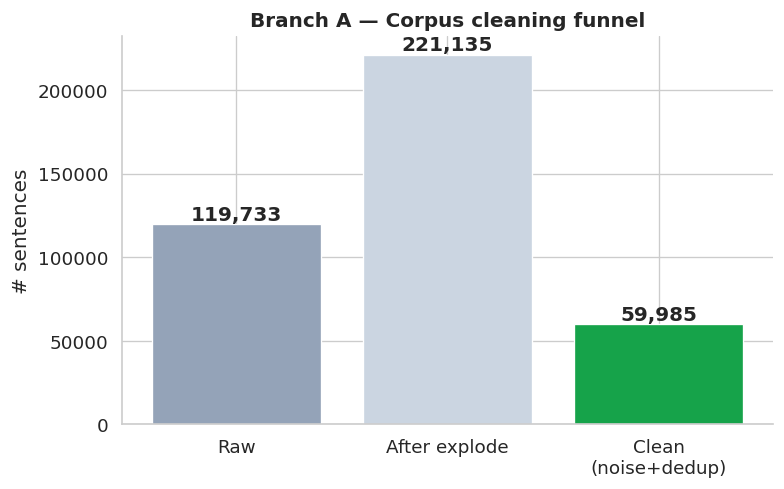

In [3]:
exp = raw["sentence"].astype(str).str.split("\n").explode()
exp = exp.str.replace(r"^\s*[-–—•»*+]+\s*", "", regex=True).str.strip()
exp = exp[exp.str.len() > 0]
stages = {"Raw": len(raw), "After explode": len(exp), "Clean\n(noise+dedup)": len(clean)}
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(range(len(stages)), list(stages.values()), color=["#94a3b8", "#cbd5e1", "#16a34a"])
ax.set_xticks(range(len(stages))); ax.set_xticklabels(list(stages.keys()))
ax.set_ylabel("# sentences"); ax.set_title("Branch A — Corpus cleaning funnel")
for b, v in zip(bars, stages.values()):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
savefig("corpus_funnel"); plt.show()

## 2. Noise indicators in the raw corpus
Descriptive share of raw sentences flagged by the main structural rules (table pipes, embedded newlines, blobs, fragments, number-heavy rows).

saved -> figures/phase01/corpus_noise_indicators.png (+pdf)


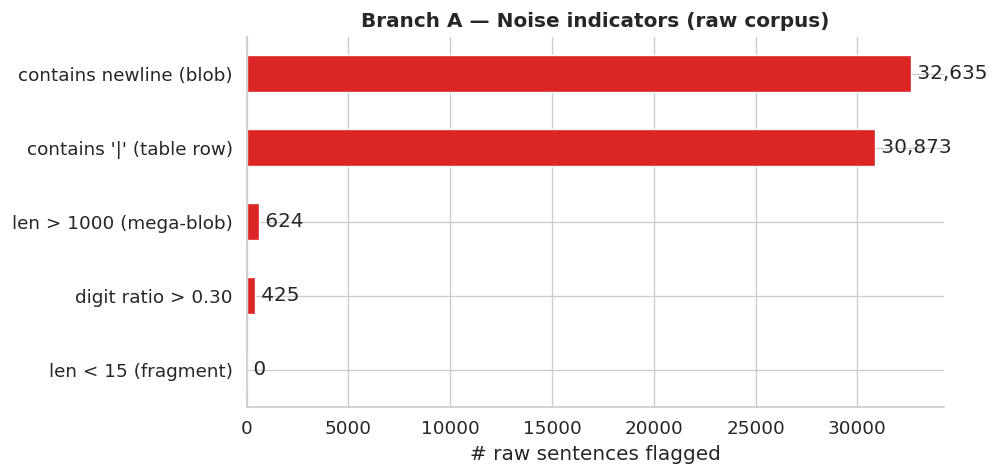

In [4]:
s = raw["sentence"].astype(str)
rules = {
    "contains '|' (table row)": s.str.contains("|", regex=False),
    "contains newline (blob)": s.str.contains("\n", regex=False),
    "len > 1000 (mega-blob)": s.str.len() > 1000,
    "len < 15 (fragment)": s.str.len() < 15,
    "digit ratio > 0.30": s.apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1) > 0.30),
}
counts = pd.Series({k: int(v.sum()) for k, v in rules.items()}).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4))
counts.plot.barh(ax=ax, color="#dc2626")
ax.set_xlabel("# raw sentences flagged"); ax.set_title("Branch A — Noise indicators (raw corpus)")
for i, v in enumerate(counts):
    ax.text(v, i, f" {v:,}", va="center")
savefig("corpus_noise_indicators"); plt.show()

## 3. Sentence-length distribution: before vs after

saved -> figures/phase01/corpus_length_dist.png (+pdf)


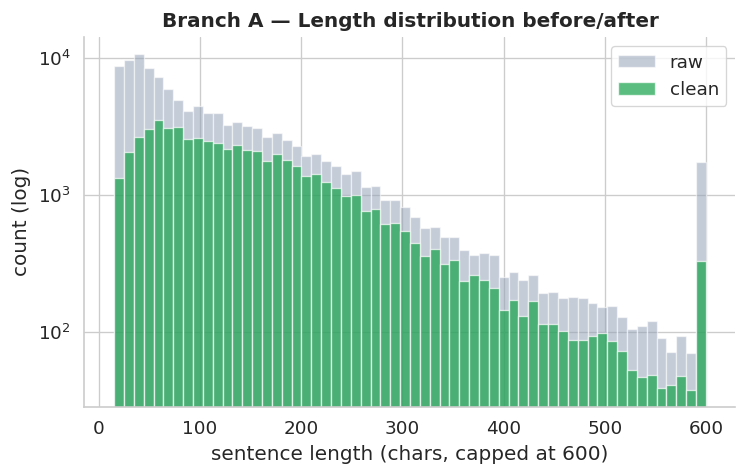

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(raw["sentence"].str.len().clip(upper=600), bins=60, alpha=0.55, label="raw", color="#94a3b8")
ax.hist(clean["sentence"].str.len().clip(upper=600), bins=60, alpha=0.7, label="clean", color="#16a34a")
ax.set_xlabel("sentence length (chars, capped at 600)"); ax.set_ylabel("count (log)")
ax.set_yscale("log"); ax.set_title("Branch A — Length distribution before/after"); ax.legend()
savefig("corpus_length_dist"); plt.show()

## 4. Coverage: clean sentences per bank-year

saved -> figures/phase01/corpus_coverage_heatmap.png (+pdf)


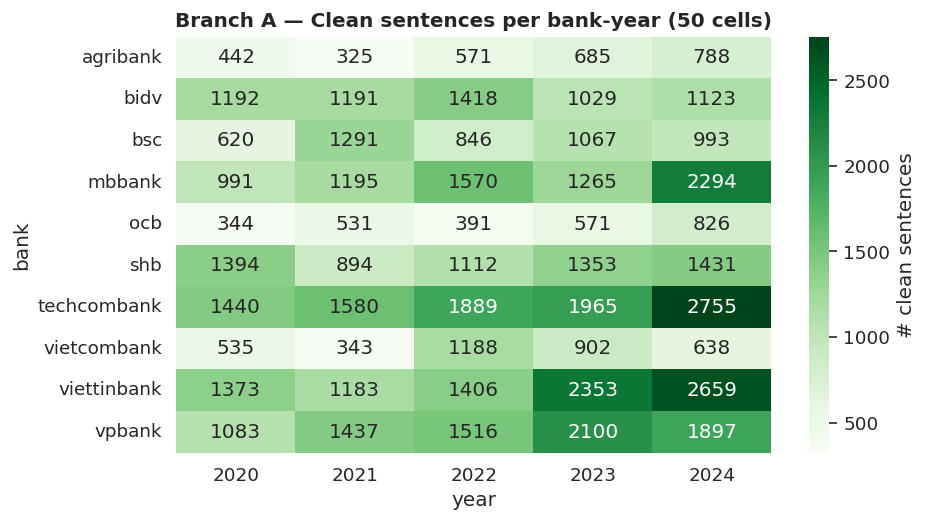

In [6]:
piv = clean.groupby(["bank", "year"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(piv, annot=True, fmt="d", cmap="Greens", ax=ax, cbar_kws={"label": "# clean sentences"})
ax.set_title("Branch A — Clean sentences per bank-year (50 cells)")
ax.set_xlabel("year"); ax.set_ylabel("bank")
savefig("corpus_coverage_heatmap"); plt.show()

## 5. Qualitative check: removed (noise) vs kept (narrative)

In [7]:
removed = raw[~raw["sentence"].isin(set(clean["sentence"]))]
print("REMOVED (noise) examples:")
for x in removed["sentence"].astype(str).sample(6, random_state=1):
    print("  x", x[:100])
print("\nKEPT (narrative) examples:")
for x in clean["sentence"].astype(str).sample(6, random_state=1):
    print("  +", x[:100])

REMOVED (noise) examples:
  x 743 | (35) |
| Tiền thu từ bán bất động sản đầu tư | | 736.
  x Dự phòng chung tại ngày 31 tháng 12 được tính dựa trên kết quả phân loại nợ và số dư nợ gốc tại ngày
  x | Thu nhập lãi và các khoản thu nhập tương tự nhận được | 130.
  x 103 |
| Tiền gửi tại Ngân hàng Nhà nước Lào (ii) | 370.
  x | Phân loại theo "ối tượng "ào tạo | Số ngày "ào tạo trung bình | Lượt "ào tạo |
|------------------
  x Công ty quản lý rủi ro lãi suất bằng cách phân tích tình hình cạnh tranh trên thị trường để có các m

KEPT (narrative) examples:
  + quá trình nghiên cứu, áp dụng
  + Dự phòng giảm giá được tính bằng tổng vốn đầu tư
  + Ngân hàng sẽ tiếp tục xây dựng những chiến lược ngành linh hoạt "ể cạnh tranh và thâm nhập mạnh mẽ t
  + NFI năm 2024 đạt 4,4 nghìn tỷ, đứng thứ 6, tăng trưởng 7,1% so với năm 2023, là mức tăng trưởng cao 
  + Các chỉ tiêu hoạt động đều tăng trưởng so với năm 2020 và đạt, vượt kế hoạch đề ra.
  + Phng T doanh Trin khai cc hot đng đu t c phiu v chn

## 6. Commitment recovery via explode
Multi-line blobs hide quantified targets (the CTI signal). Explode splits them out instead of dropping the whole blob.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12576\2931279859.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  at_risk = int(blobs["sentence"].astype(str).str.contains(pat).sum())
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12576\2931279859.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  kept_numeric = int(clean["sentence"].astype(str).str.contains(pat).sum())


Raw multi-line blobs containing numeric targets (would be DROPPED w/o explode): 2,610
Numeric target/commitment sentences in CLEAN corpus (recovered as discrete rows): 7,047


saved -> figures/phase01/corpus_commitment_recovery.png (+pdf)


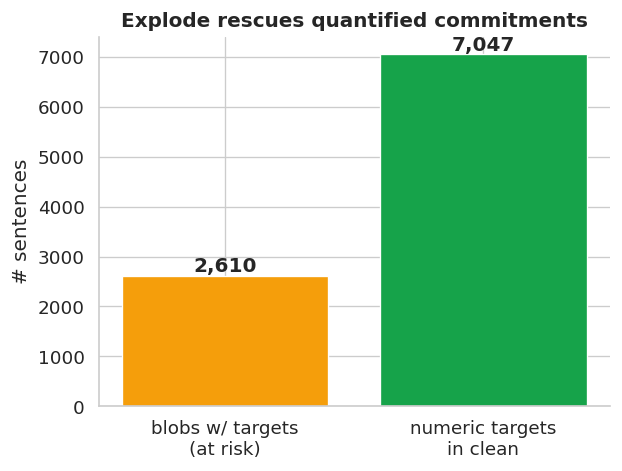

In [8]:
import re
pat = re.compile(r"(tăng|giảm|đạt|tối thiểu)[^.]{0,25}\d|\d+\s?%")
blobs = raw[raw["sentence"].astype(str).str.contains("\n", regex=False)]
at_risk = int(blobs["sentence"].astype(str).str.contains(pat).sum())
kept_numeric = int(clean["sentence"].astype(str).str.contains(pat).sum())
print(f"Raw multi-line blobs containing numeric targets (would be DROPPED w/o explode): {at_risk:,}")
print(f"Numeric target/commitment sentences in CLEAN corpus (recovered as discrete rows): {kept_numeric:,}")
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["blobs w/ targets\n(at risk)", "numeric targets\nin clean"], [at_risk, kept_numeric],
       color=["#f59e0b", "#16a34a"])
ax.set_ylabel("# sentences"); ax.set_title("Explode rescues quantified commitments")
for i, v in enumerate([at_risk, kept_numeric]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
savefig("corpus_commitment_recovery"); plt.show()